In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

from cndlles.preprocess import preprocess
from cndlles.preprocess import rotate_sample
from cndlles.preprocess import my_reshape
from cndlles.torch_arch import *
from cndlles.plot_helpers import plot_scatter

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np
import pickle
import torch

In [4]:
size=3  # Horizontal size of input planes, always 3 in vertical
Nhid = [32,16,8]  # Multiplicity of hidden layers
Ri_pct = 0.25  # Percent of first hidden layer features that are due to tranforming Ri input
Nruns = 5

In [5]:
loadFile='../training_C4DNN/trainedModels/C4_ReExtrap_'
plotQuickPlots = True
## Training datasets
files=["coarse4x1026_Re900.nc", "coarse4x2052_Re1800.nc" ] # "coarse4x1026_Re1800.nc"]

# Scaling factors based on exogenous forcing
# Note, lower Re in file names uses a viscous length scale from the
# DNS while LES scaling factors use the BL depth as length scale
fileRes=[20000.,40000.] # Re = 20k, 40k, 60k for Re900, Re1800, Re2700
fileUgs=[0.025,0.05] # 0.025, 0.05, 0.075

filemaskpercents=None

In [6]:
# Test (reported statistics) and Validation (early stopping) data
testFiles=["coarse4x3078_Re2700.nc"]
testfileUgs=[0.075]
testfileRes=[60000.]

testfilemaskpercents=None

In [7]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(torch.cuda.get_device_name(device))
else:
    device = torch.device("cpu")
print(device)

NVIDIA L40
cuda


In [8]:
for n in range(len(files)):
    isep = files[n].index('_')
    loadFile=loadFile+files[n][6:isep]+files[n][isep+1:-3]+'_'
loadDict=pickle.load( open( loadFile[:-1]+'.pkl', "rb" ) )
print('masks from '+loadFile)
plotPath='quickPlots/'

masks from ../training_C4DNN/trainedModels/C4_ReExtrap_4x1026Re900_4x2052Re1800_


In [9]:
Nruns = 5
y_text = ["tau_11", "tau_12", "tau_13","tau_22", "tau_23", "tau_33"]
r=np.empty((Nruns,len(y_text))) 
r2=np.empty((Nruns,len(y_text)))
r_270=np.empty((Nruns,len(y_text))) 
r2_270=np.empty((Nruns,len(y_text)))
auxDataDict=dict()

Train Files:
coarse4x1026_Re900.nc
Number of samples is 704184
coarse4x2052_Re1800.nc
Number of samples is 706560
output shape is (1410744, 6)
input shape was (1410744, 3, 3, 3, 3) + (1410744, 1, 1, 1)
input shape to do 3rd dimension as channel in R2Conv is (1410744, 9, 3, 3) + (1410744, 1, 1, 1)
Test Files:
coarse4x3078_Re2700.nc
Number of samples is 56548
output shape is (56548, 6)
input shape was (56548, 3, 3, 3, 3) + (56548, 1, 1, 1)
input shape is (56548, 3, 3, 3, 3) + (56548, 1, 1, 1)
Train Files:
coarse4x1026_Re900.nc
Number of samples is 704447
coarse4x2052_Re1800.nc
Number of samples is 706560
output shape is (1411007, 6)
input shape was (1411007, 3, 3, 3, 3) + (1411007, 1, 1, 1)
input shape to do 3rd dimension as channel in R2Conv is (1411007, 9, 3, 3) + (1411007, 1, 1, 1)
Test Files:
coarse4x3078_Re2700.nc
Number of samples is 56549
output shape is (56549, 6)
input shape was (56549, 3, 3, 3, 3) + (56549, 1, 1, 1)
input shape is (56549, 3, 3, 3, 3) + (56549, 1, 1, 1)
Train Fi

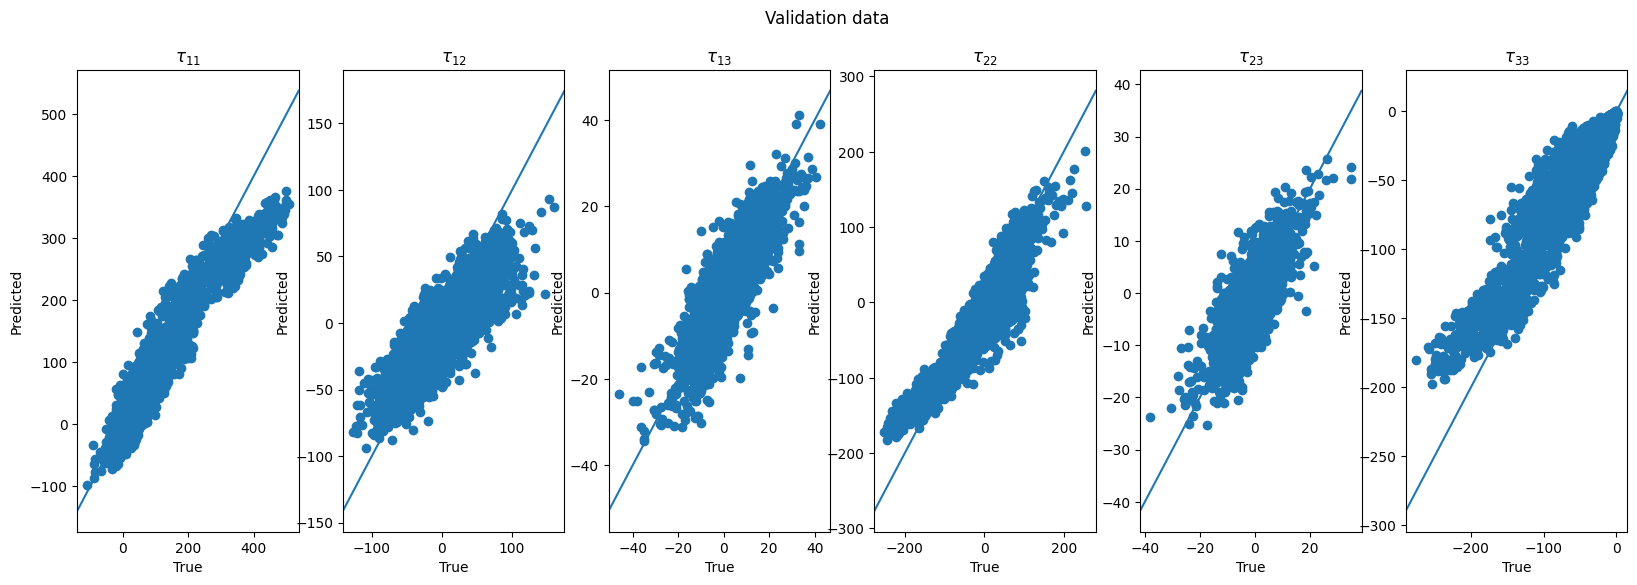

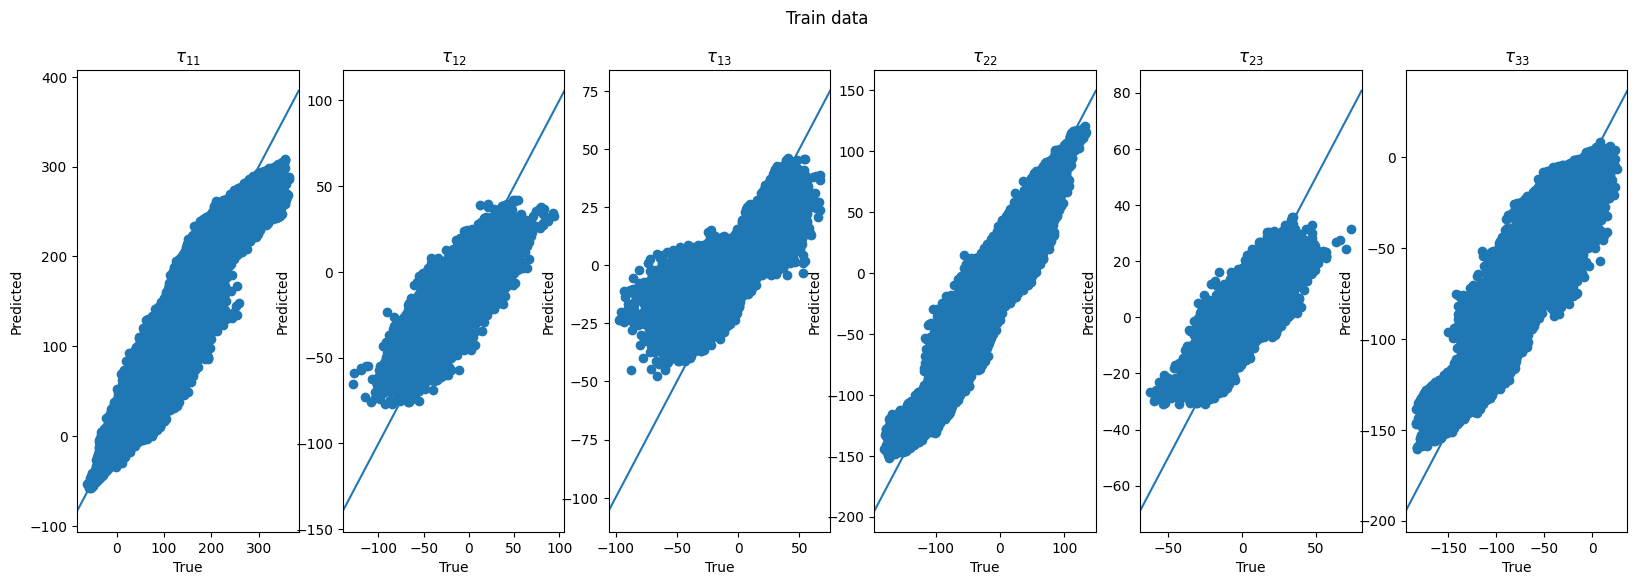

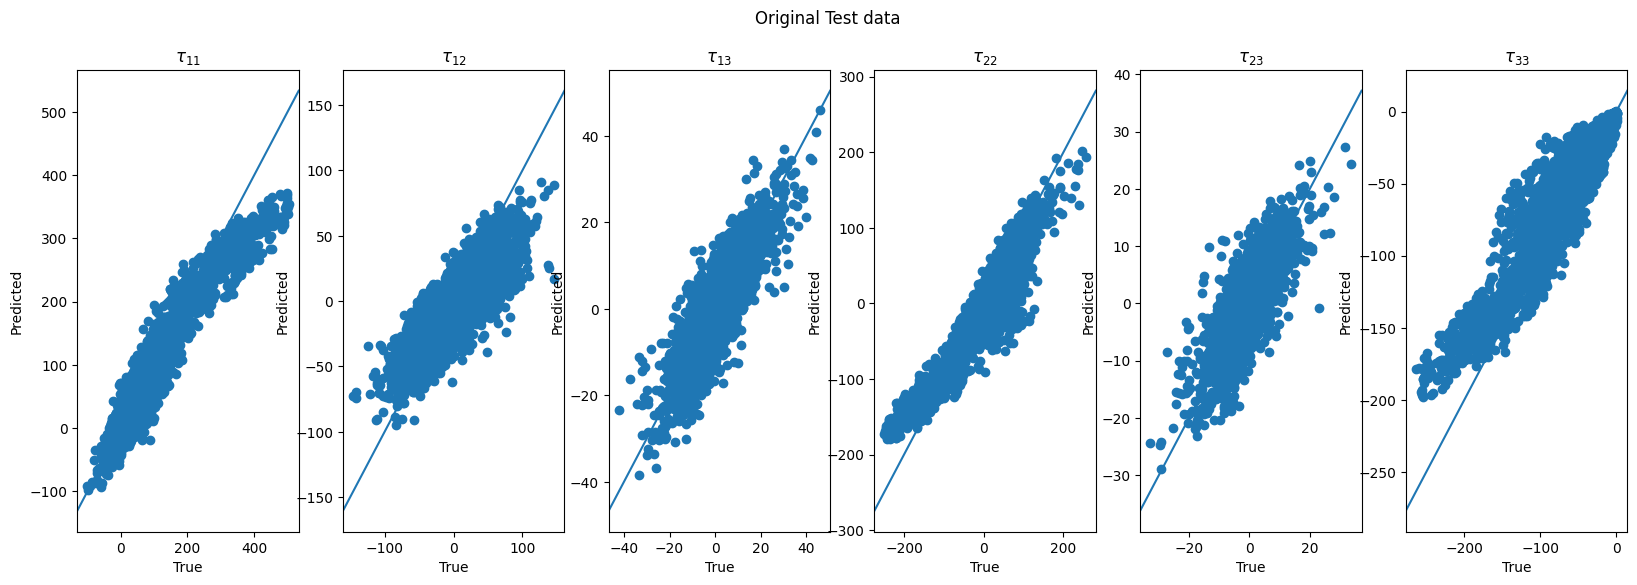

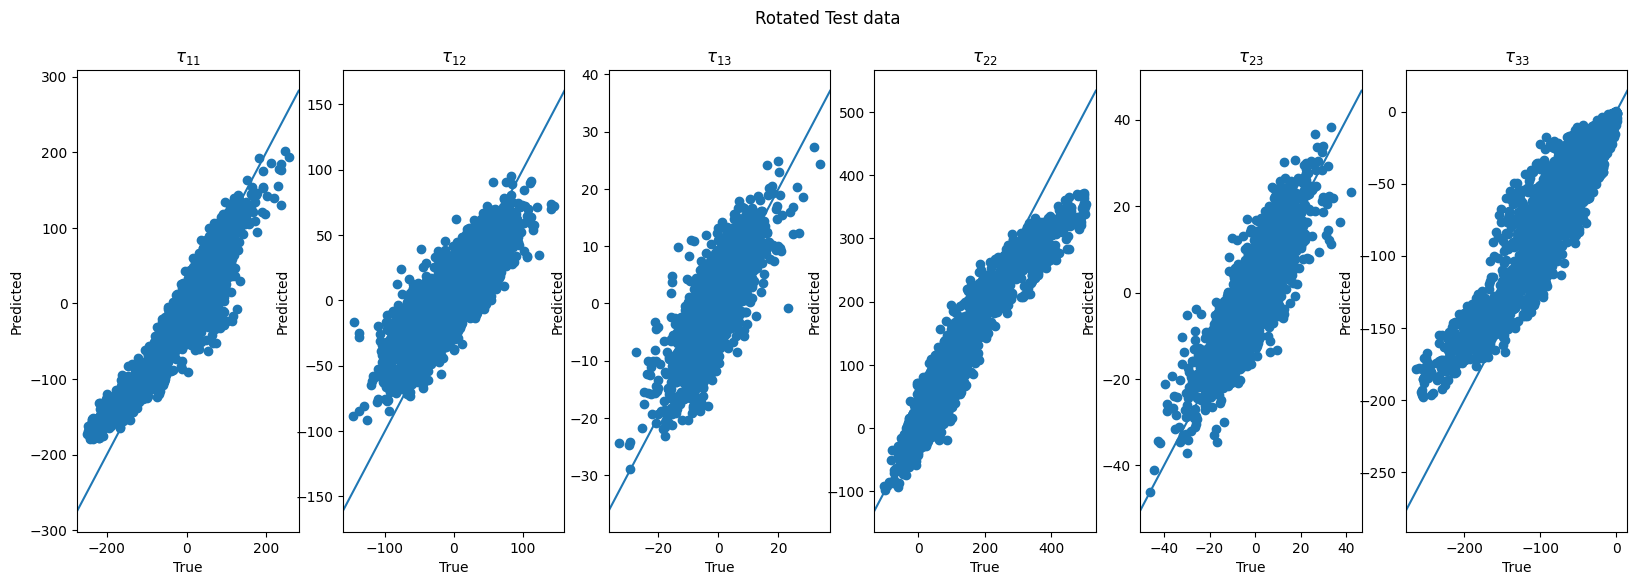

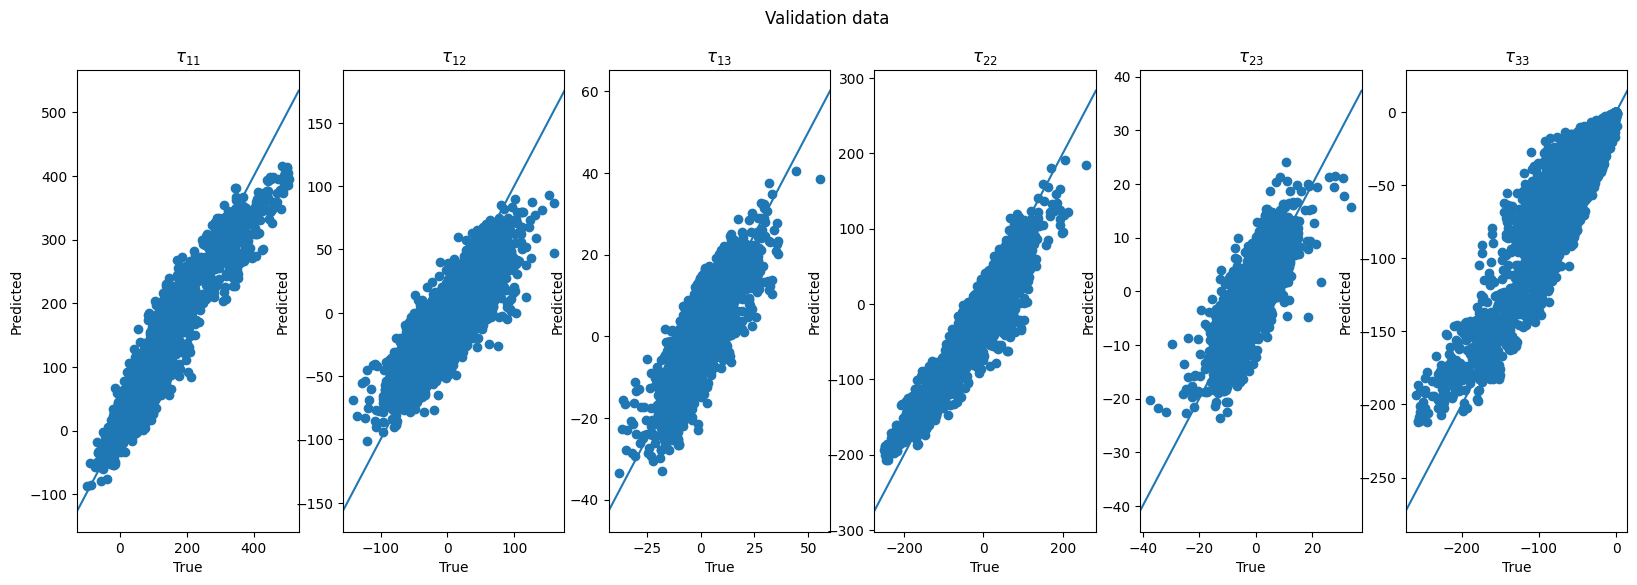

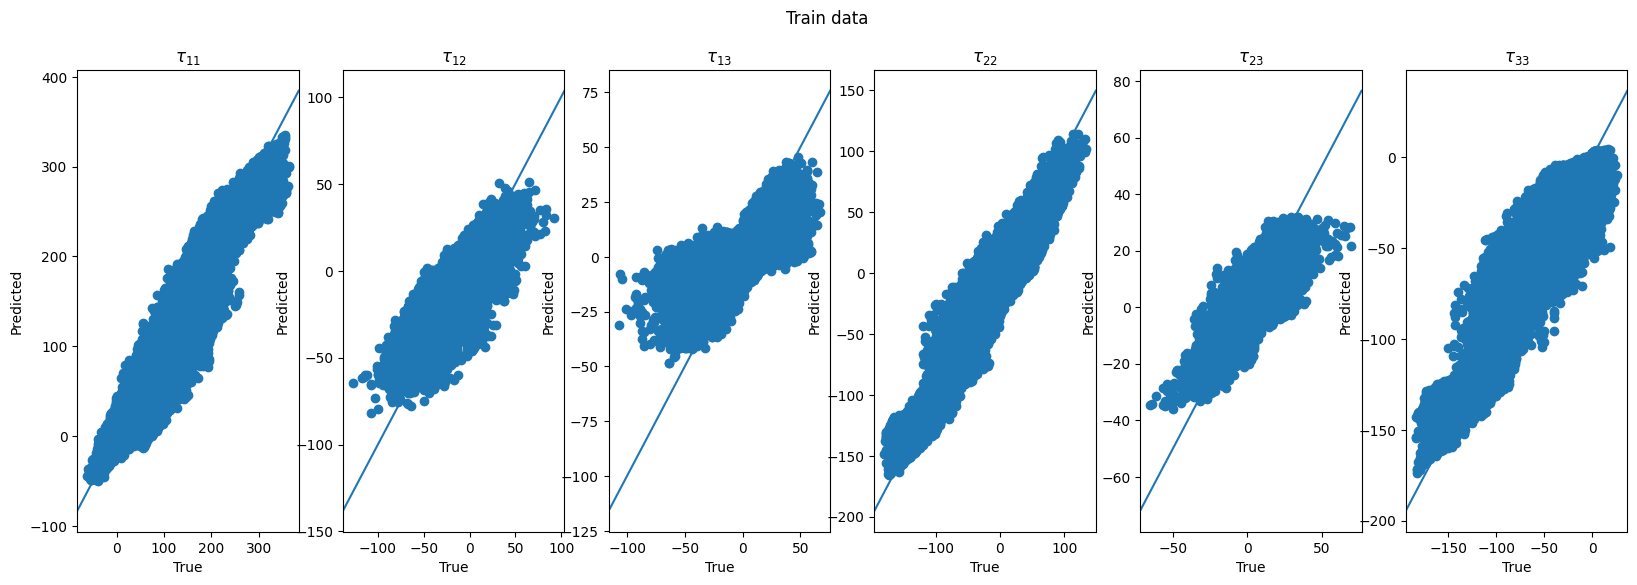

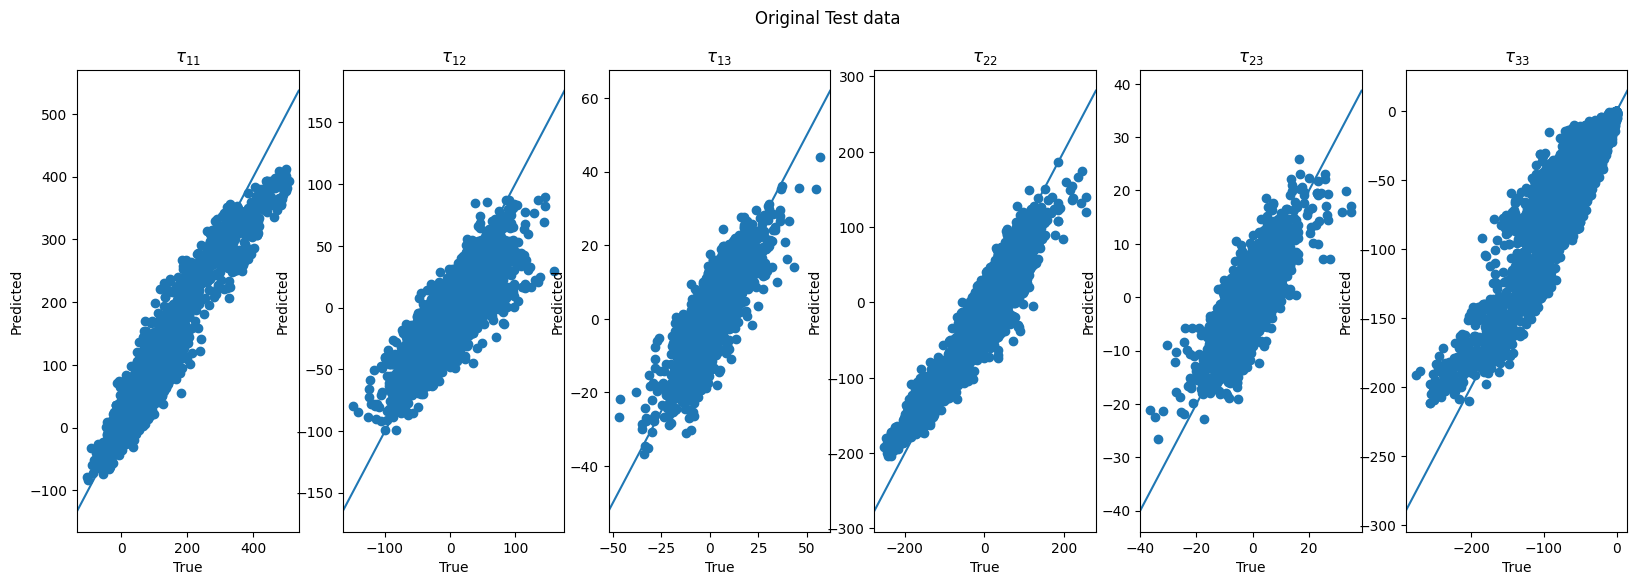

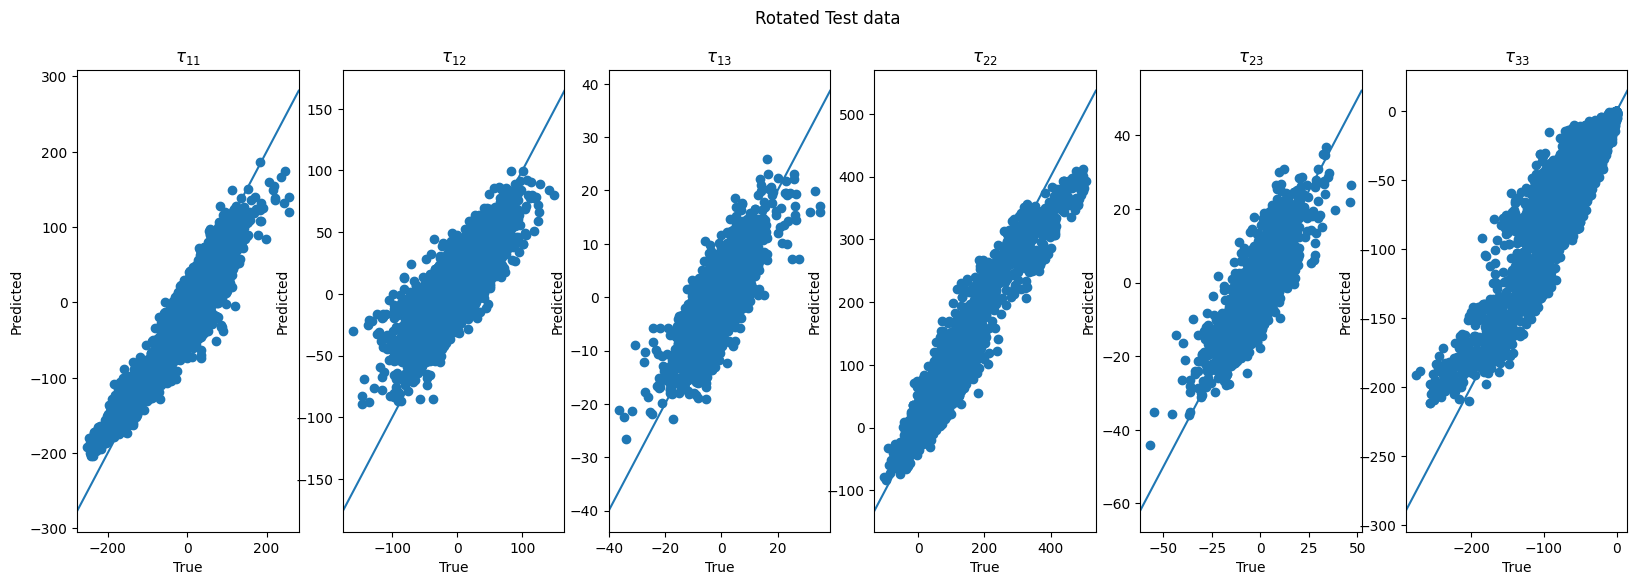

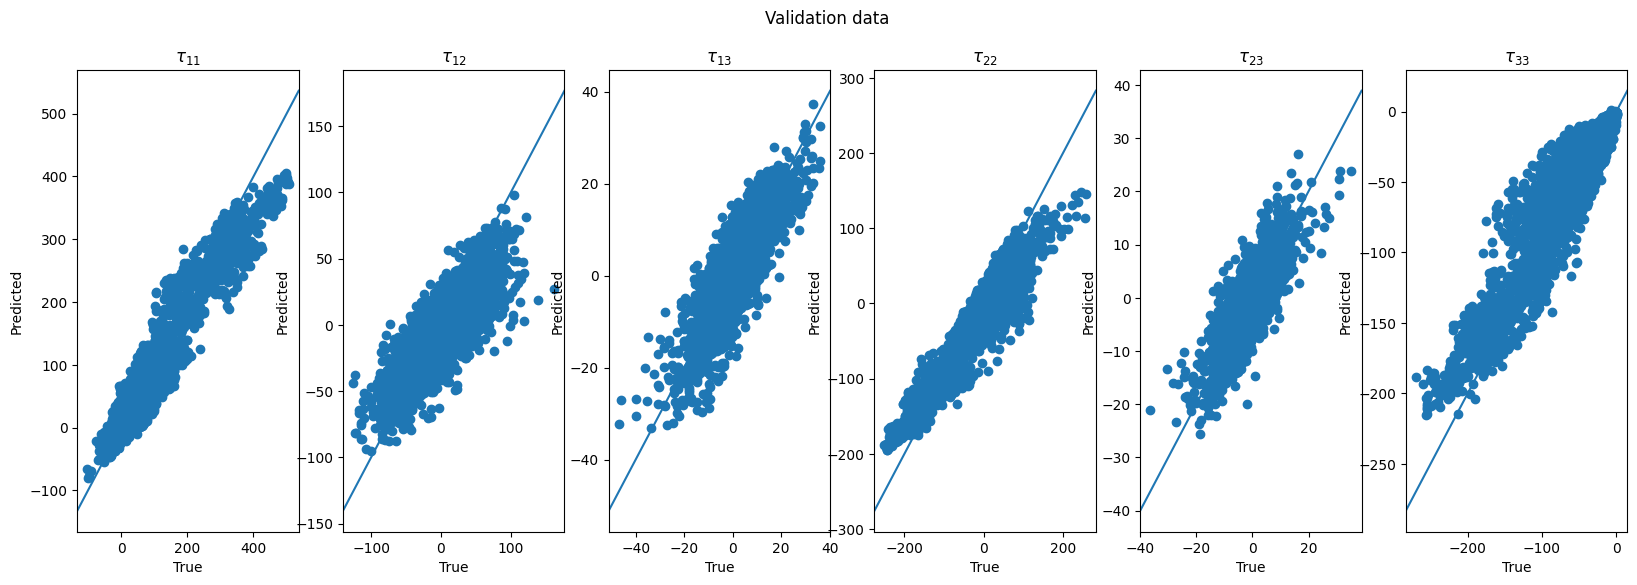

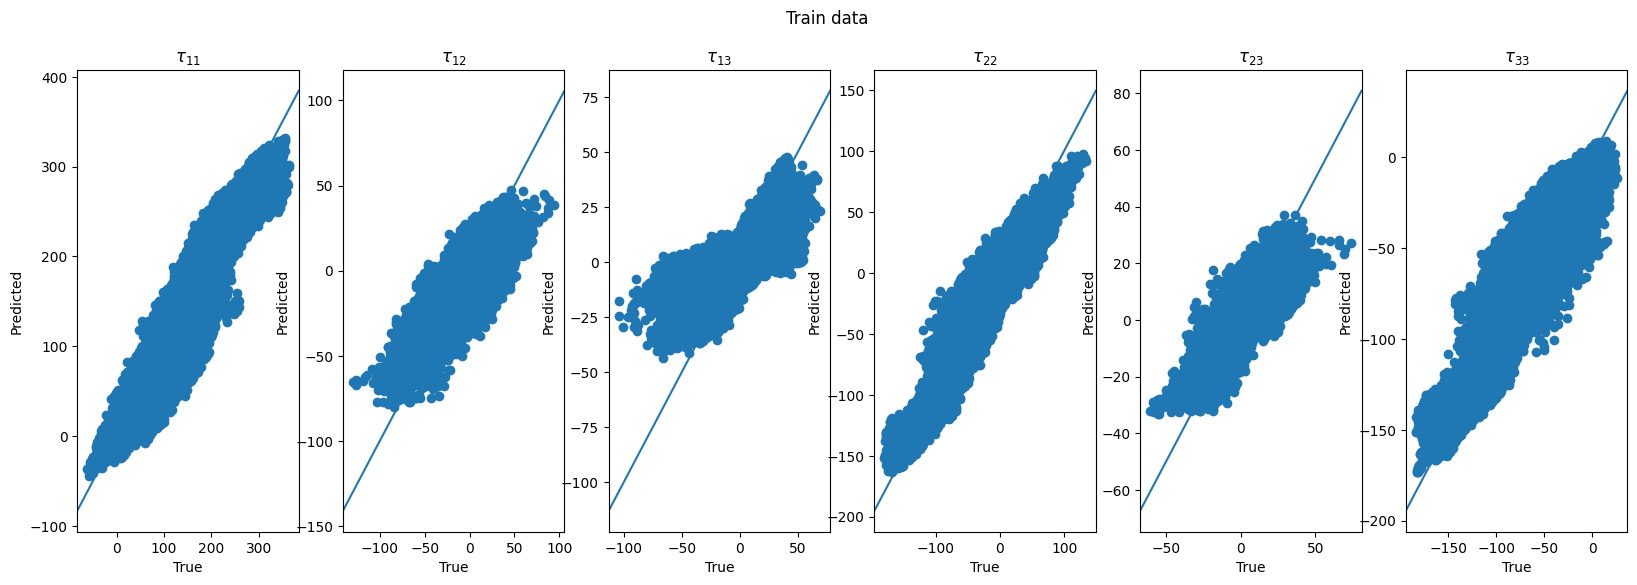

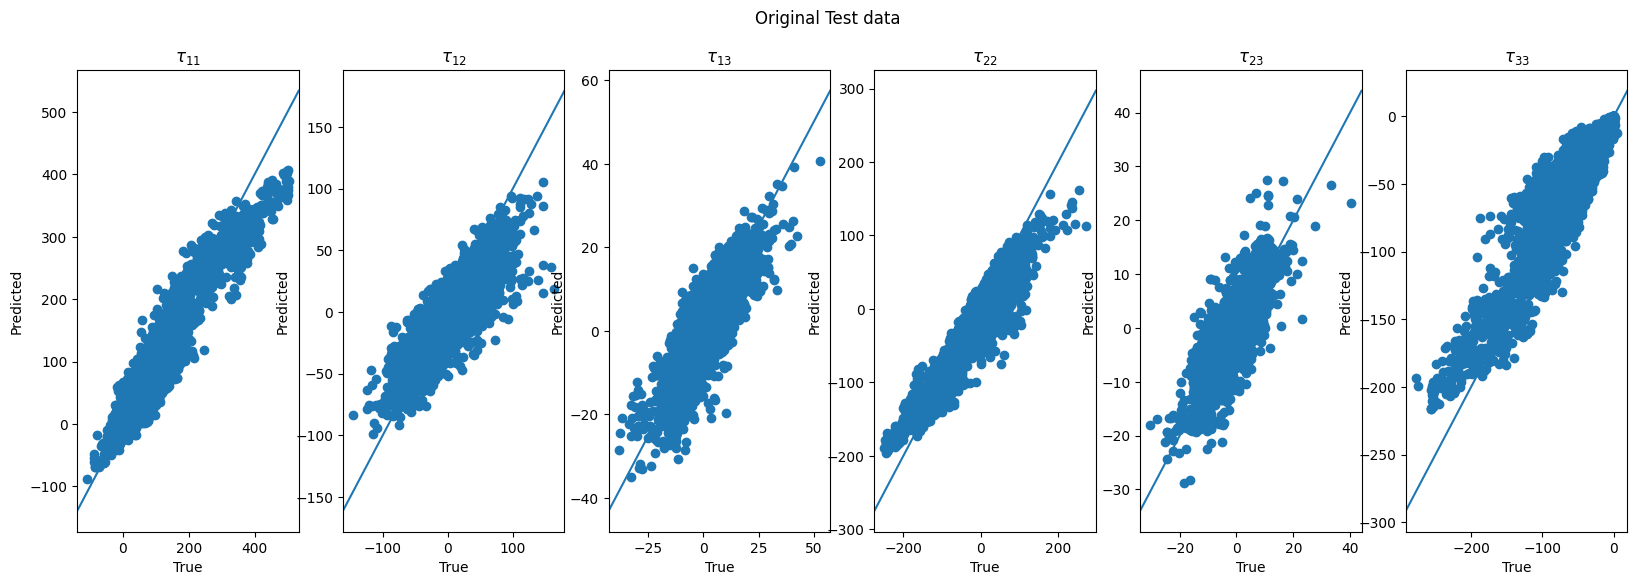

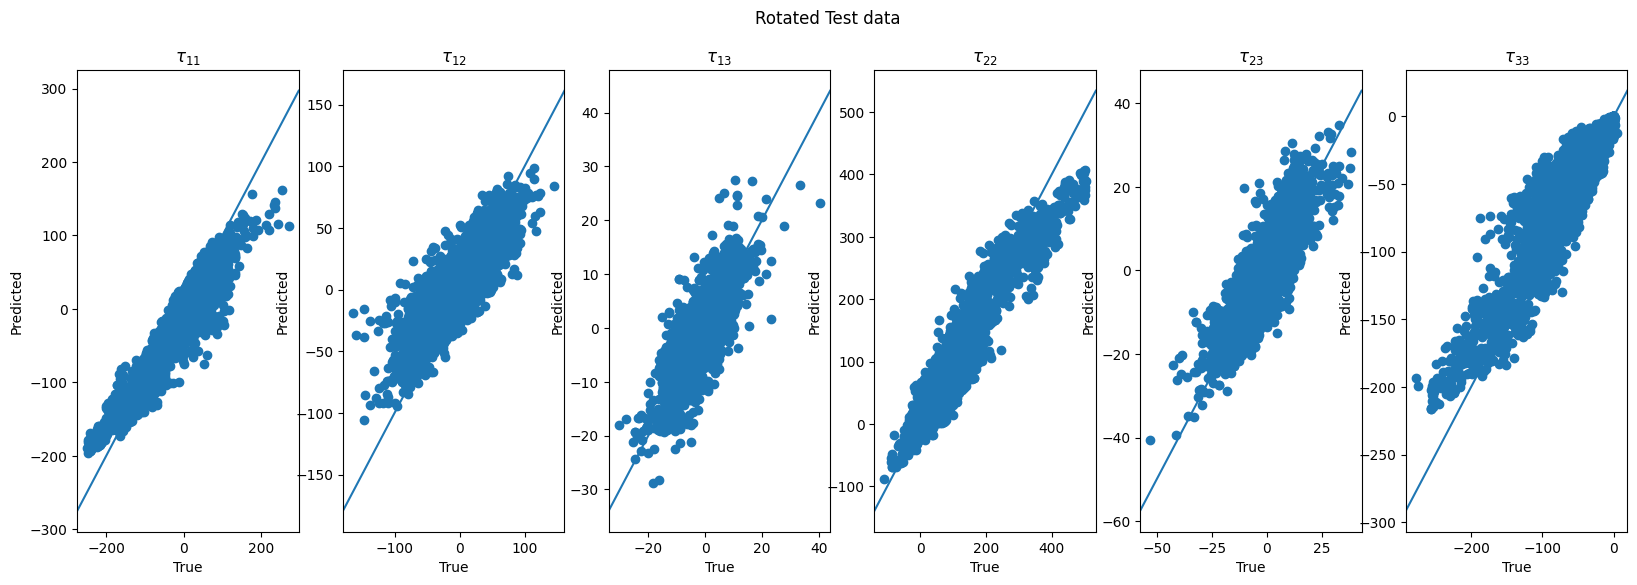

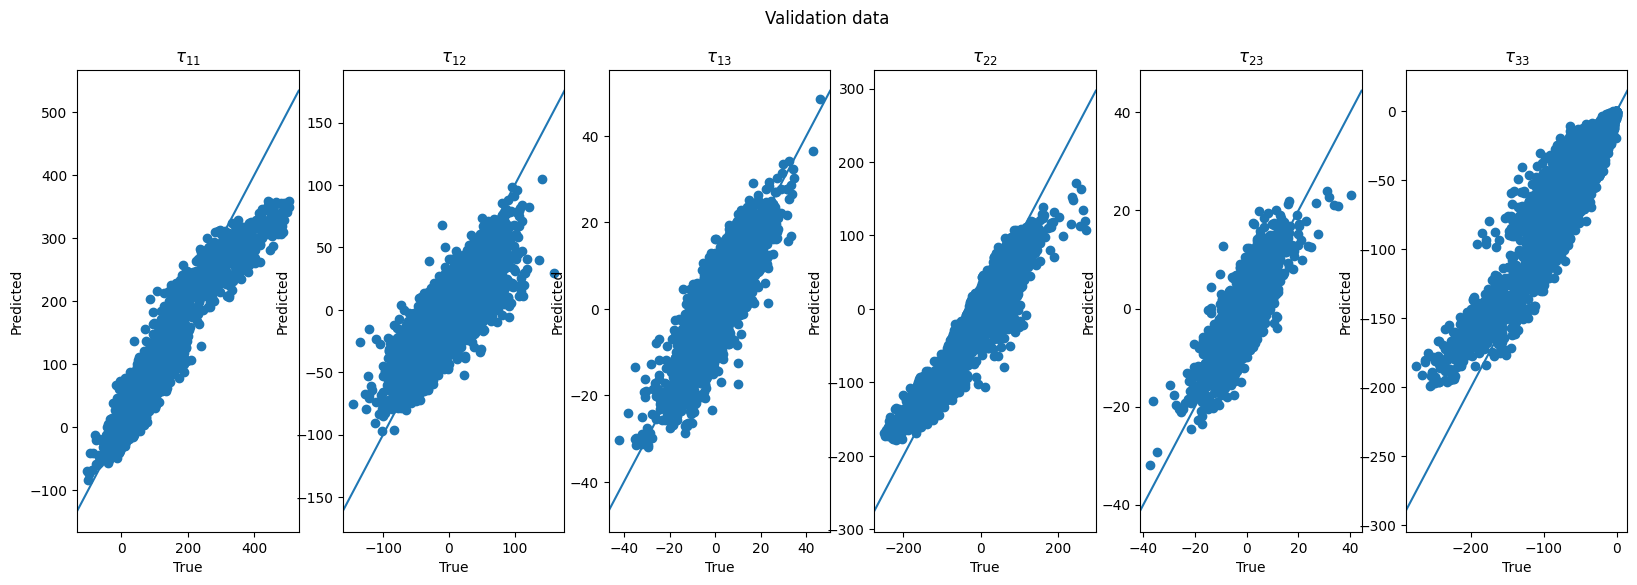

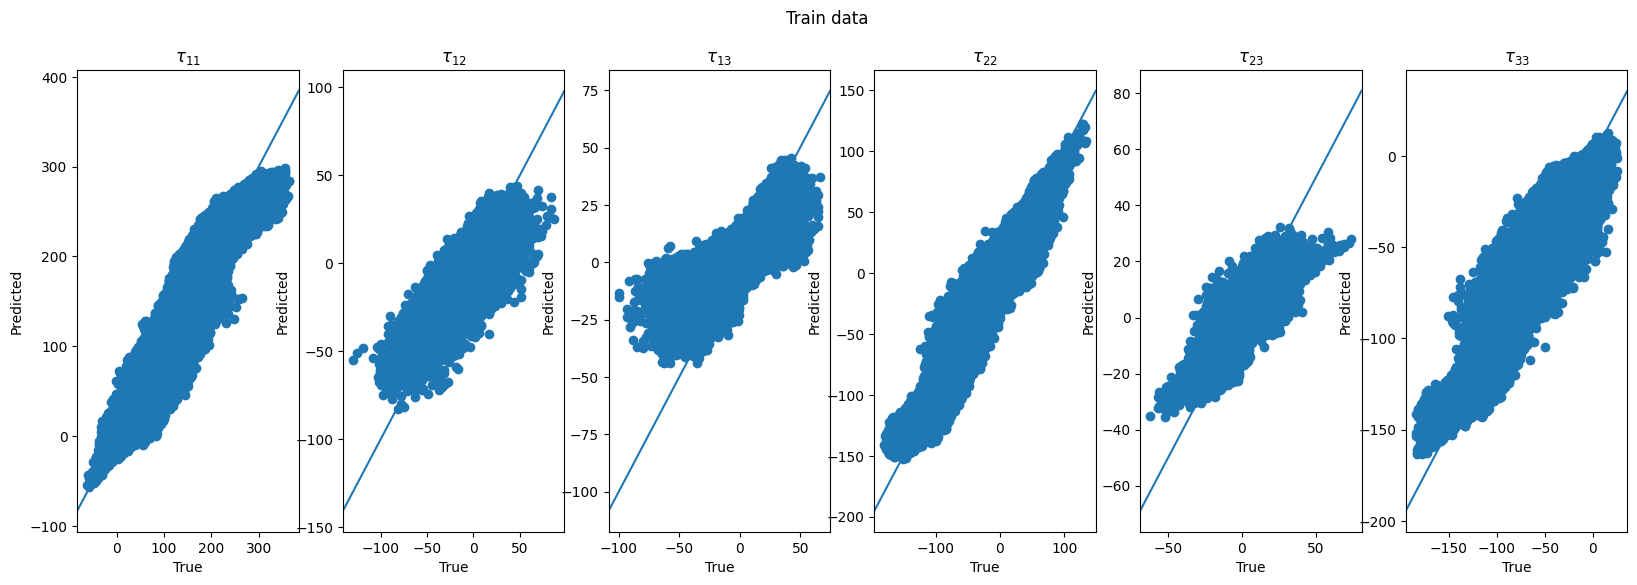

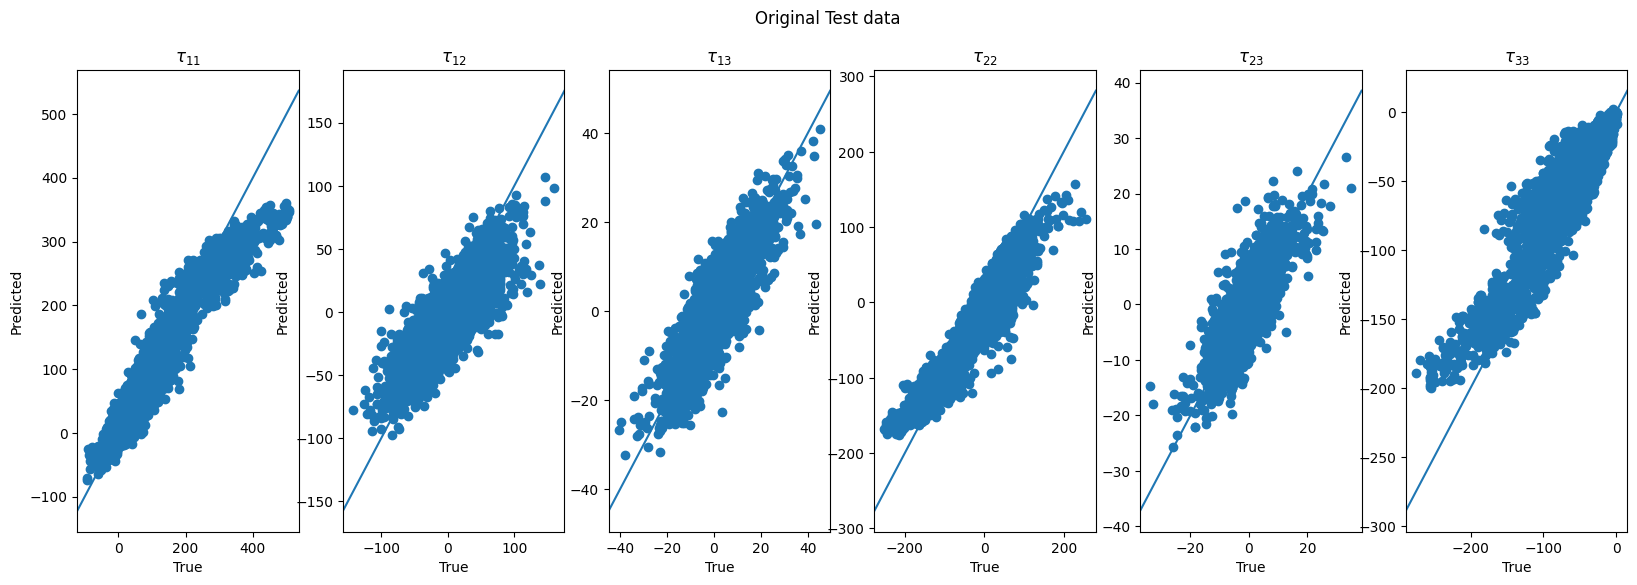

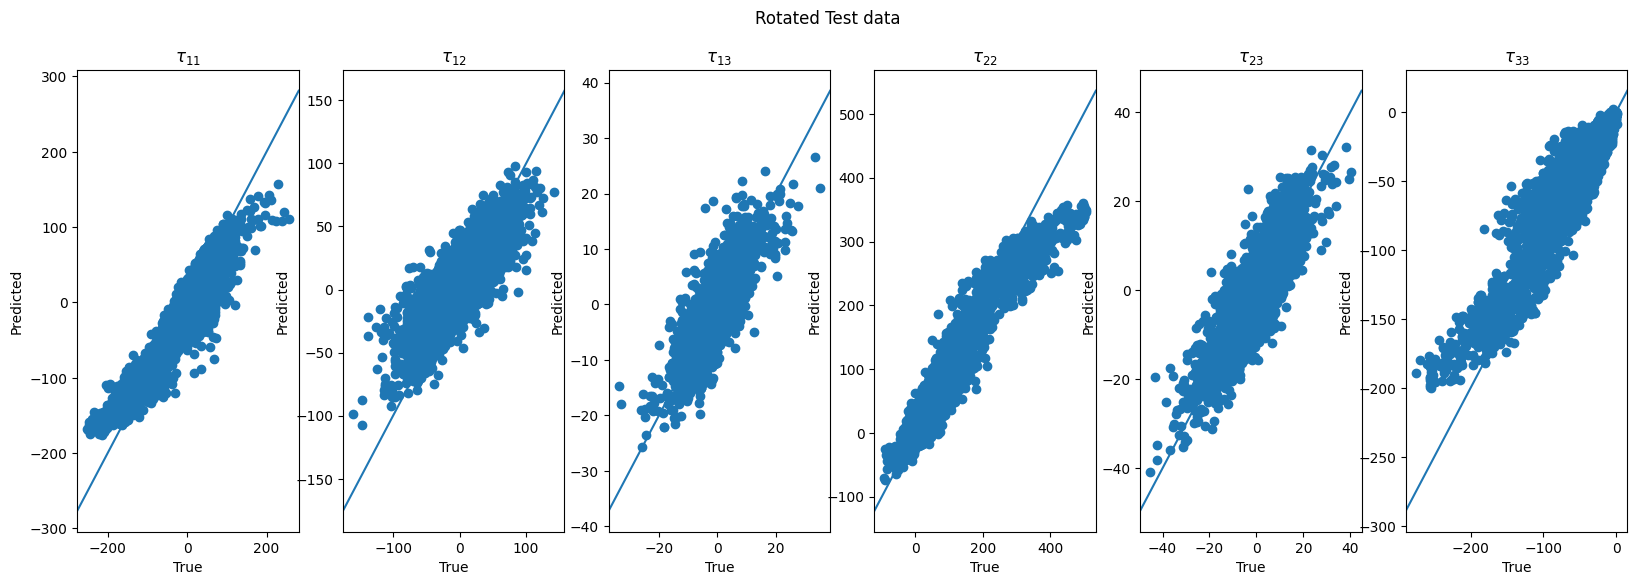

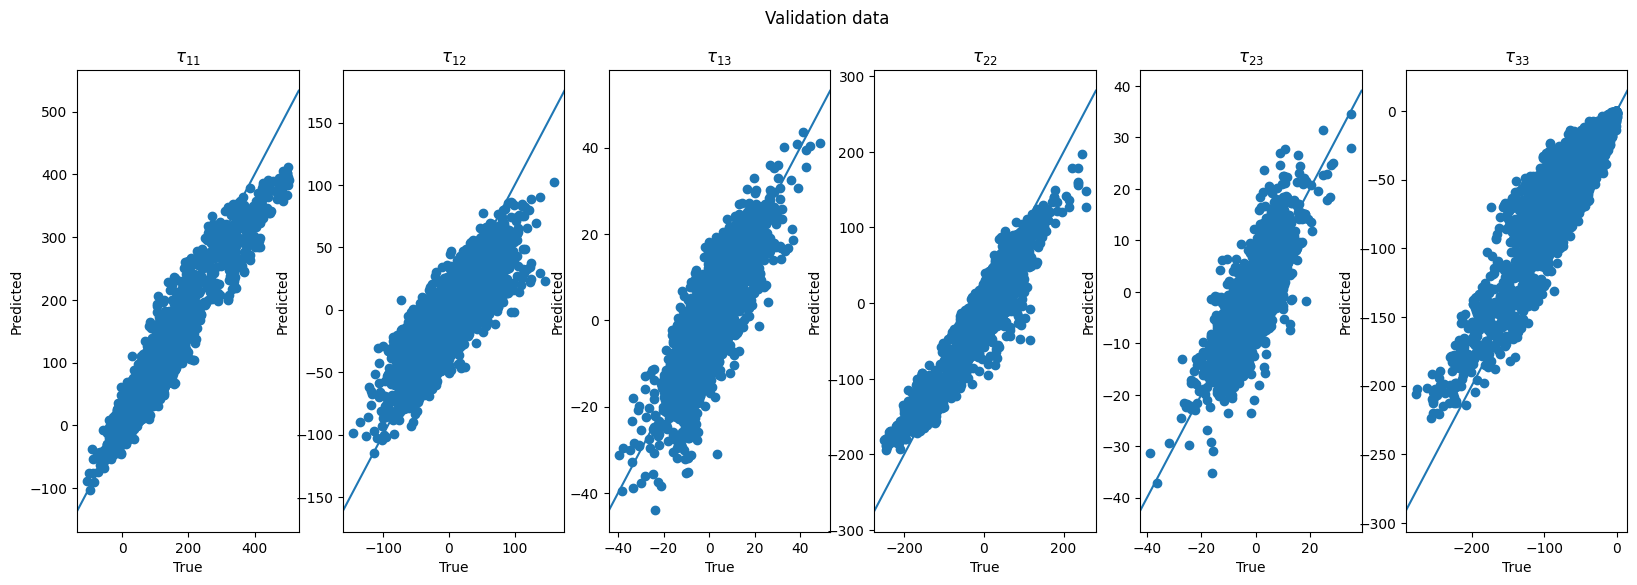

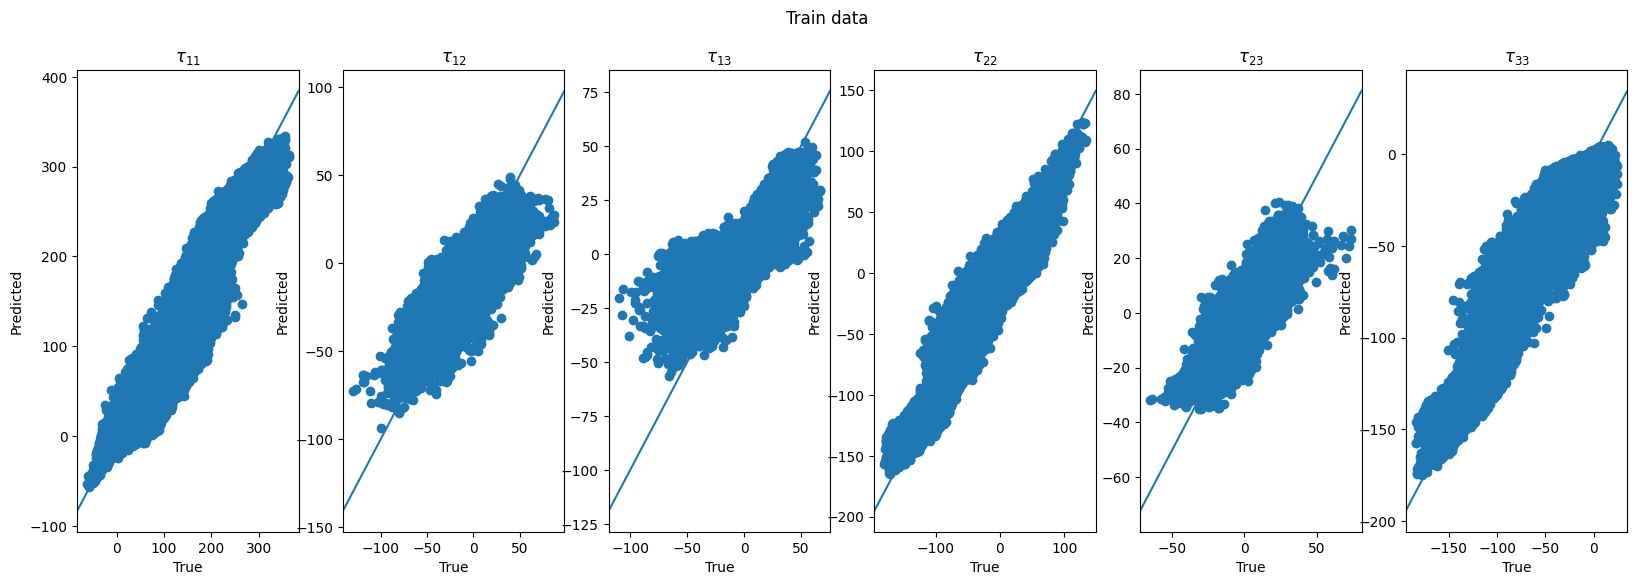

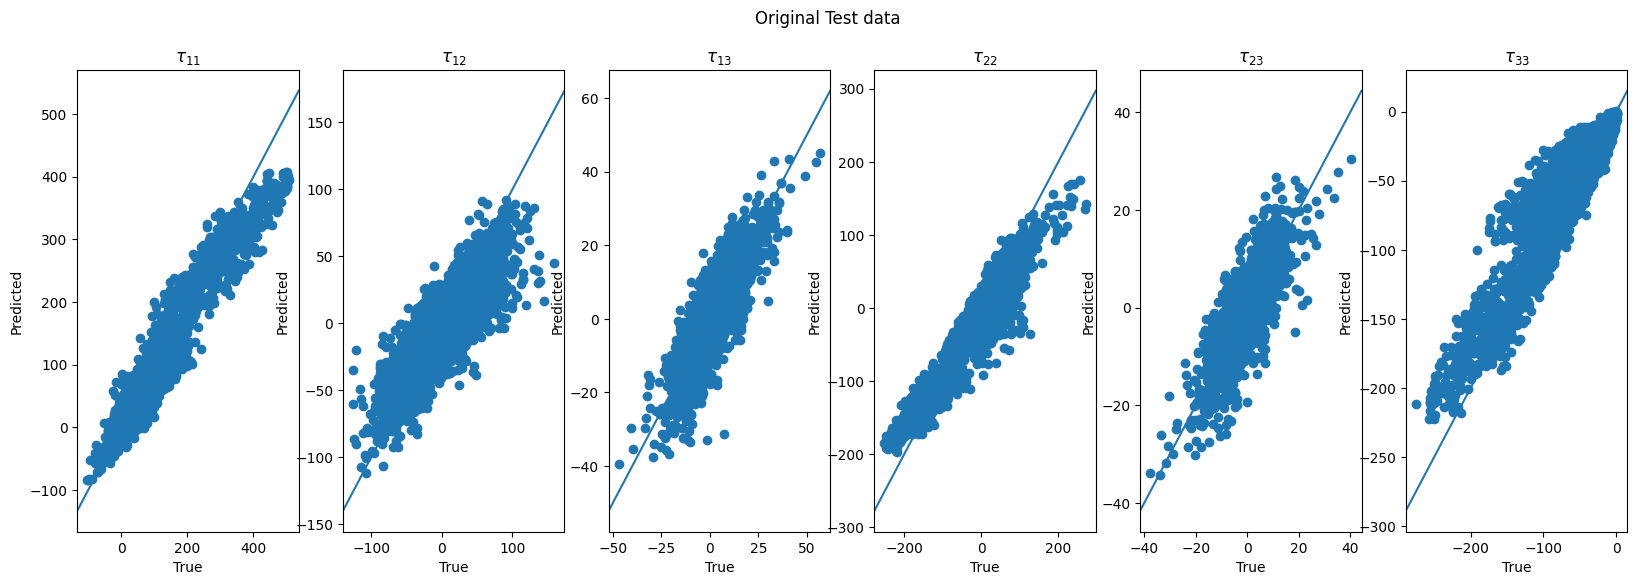

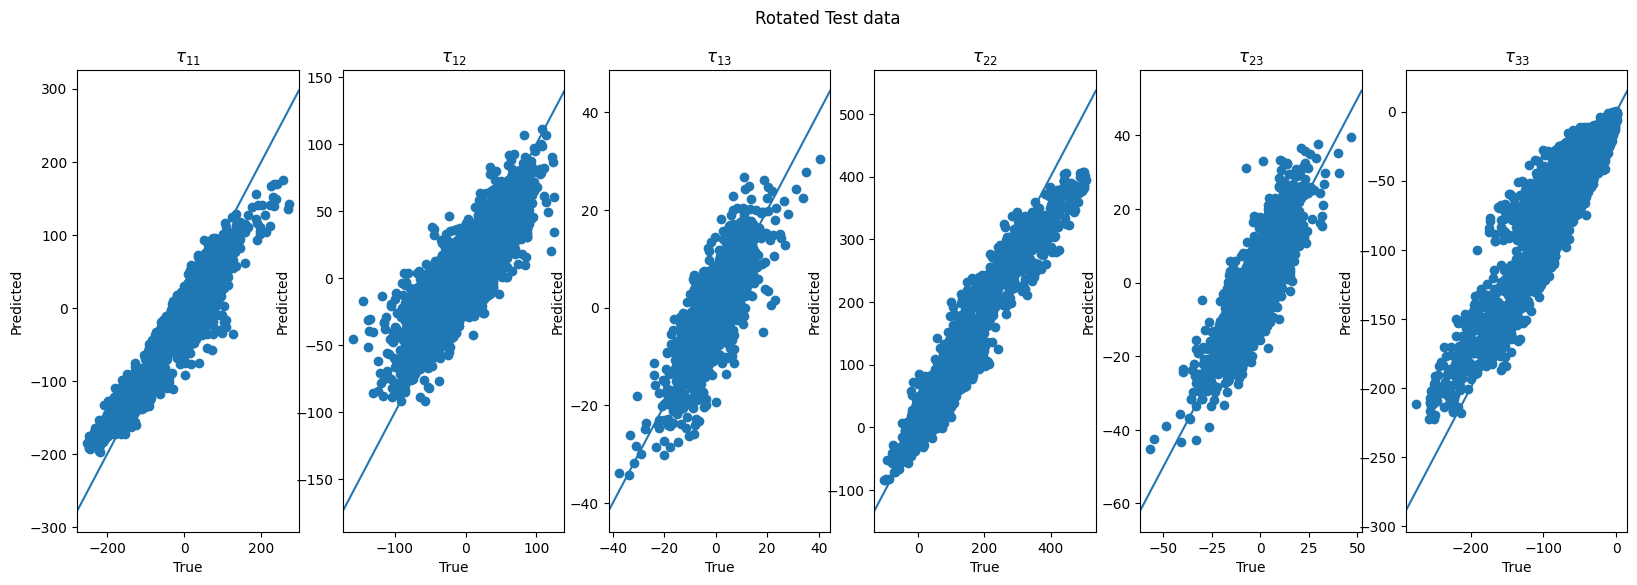

In [10]:
for irun in range(Nruns):

    print("Train Files:")
    u_train, Ri_train, y_train, trainMask = preprocess(files, filemaskpercents, fileUgs, fileRes,
                                                       size, irun, maskdict = loadDict)
    auxDataDict.update(trainMask)

    print("Test Files:")
    utest, Ritest, ytest, testMask = preprocess(testFiles, testfilemaskpercents, testfileUgs, testfileRes,
                                                size, irun, reshape = False, maskdict = loadDict)
    auxDataDict.update(testMask) 

    # Note, mask_[irun]_* uses original spatial indices, but valMask is by sample
    mask =  loadDict["valMask_"+str(irun)]
    u_test=utest[mask]
    Ri_test=Ritest[mask]
    u_val=my_reshape(utest[~mask])
    Ri_val=Ritest[~mask]
    del utest, Ritest
    y_test=ytest[mask]
    y_val=ytest[~mask]
    del ytest
    
    u_rot, y_rot = np.empty(u_test.shape),np.empty(y_test.shape)
    krot=3
    for isamp in range(y_test.shape[0]):
        u_rot[isamp], y_rot[isamp] = rotate_sample(u_test[isamp], y_test[isamp], krot)
    u_test=my_reshape(u_test)
    u_rot=my_reshape(u_rot)

    model=CNDNN(Nhid, Ri_pct = Ri_pct,N=4,size=size).float().to(device)

    # Reloading best model weights
    model.load_state_dict(torch.load(loadFile+str(irun)+'.pt', map_location=device))

    if plotQuickPlots:
        plot_scatter(model, device,
                                u_val, Ri_val, y_val,
                                # weights = LossWeights,
                                text = "Validation data",
                   )
    
        plot_scatter(model, device,
                                u_train, Ri_train, y_train,
                                # weights = LossWeights,
                                text = "Train data",
                   )
        
        y_pred = plot_scatter(model, device,
                                u_test, Ri_test, y_test,
                                # weights = LossWeights,
                                text = "Original Test data",
                                return_predictions = True
                   )

        y_pred270 = plot_scatter(model, device,
                                u_rot, Ri_test, y_rot,
                                # weights = LossWeights,
                                text = "Rotated Test data",
                                return_predictions = True
                   )

    # else: # Not implemented b/c always want to plot and return predictions then
    #     yp = get_predictions( <Test Data> ) # to save on inference

    r2[irun]=[r2_score(y_test[:,i], y_pred[:,i]) for i in range(y_pred.shape[1])]
    r[irun]=[np.corrcoef(y_test[:,i], y_pred[:,i])[0, 1] for i in range(y_pred.shape[1])]

    r2_270[irun]=[r2_score(y_rot[:,i], y_pred270[:,i]) for i in range(y_pred.shape[1])]
    r_270[irun]=[np.corrcoef(y_rot[:,i], y_pred270[:,i])[0, 1] for i in range(y_pred.shape[1])]
    
    del model


In [11]:
print('Original orientation')
print(r)
print(r2)
auxDataDict["r"] = r
auxDataDict["Rsquared"] = r2
for v in range(r2.shape[1]):
        print(y_text[v]+r' avg. R$^2$ is '+str(np.mean(r2[:,v]))+' +/- '+str(np.std(r2[:,v])))
print(r'Overall avg. R$^2$ is '+str(np.mean(r2))+' +/- '+str(np.std(np.mean(r2,axis=1))))

print()

print('Rotated by 270deg:')
print(r_270)
print(r2_270)
auxDataDict["r_270"] = r_270
auxDataDict["Rsquared_270"] = r2_270
for v in range(r2.shape[1]):
        print(y_text[v]+r' avg. R$^2$ is '+str(np.mean(r2_270[:,v]))+' +/- '+str(np.std(r2_270[:,v])))
print(r'Overall avg. R$^2$ is '+str(np.mean(r2_270))+' +/- '+str(np.std(np.mean(r2_270,axis=1))))

saveFile='./C4_ReExtrap_test270'
pickle.dump(auxDataDict,open(saveFile+'.pkl', "wb" ))

Original orientation
[[0.96083633 0.8317784  0.84271896 0.90868917 0.78685344 0.95544694]
 [0.96557725 0.82798739 0.83426063 0.91541528 0.78734922 0.95183127]
 [0.96332819 0.83758693 0.84055829 0.90620852 0.78175195 0.95180537]
 [0.96212108 0.82696549 0.84943075 0.90644438 0.79570069 0.95509724]
 [0.96784242 0.83714181 0.83374829 0.91511574 0.78959204 0.95494608]]
[[0.91235688 0.67828195 0.68562188 0.81956849 0.59683685 0.88644462]
 [0.92901413 0.67632761 0.6801904  0.832244   0.60946437 0.8908342 ]
 [0.92116383 0.69171243 0.68406338 0.81207063 0.57695863 0.88786933]
 [0.91333028 0.67438858 0.6981338  0.8145889  0.6040937  0.88957257]
 [0.92854251 0.69207012 0.64632593 0.82831166 0.58362707 0.8843638 ]]
tau_11 avg. R$^2$ is 0.9208815275820612 +/- 0.007135834272748953
tau_12 avg. R$^2$ is 0.6825561364244876 +/- 0.0077217327580004725
tau_13 avg. R$^2$ is 0.6788670781527631 +/- 0.01734654379469352
tau_22 avg. R$^2$ is 0.8213567368026705 +/- 0.007773501919641522
tau_23 avg. R$^2$ is 0.5941